# V4.1 — 04: Final Evaluation, Benchmark & Inference


## Bootstrap
Mendefinisikan ulang `step_stage`, `require_vars`, dan path modul yang tidak tersimpan di `pipeline_state.pkl`.

In [ ]:
# ============================================================
#  Bootstrap: definisi runtime yang tidak tersimpan di pipeline_state.pkl
#  Dijalankan otomatis sebelum state recovery di setiap notebook serial.
# ============================================================
import os, sys, time, json, re, pickle, shutil, glob, importlib, warnings
from datetime import datetime

# --- step_stage & require_vars (dari sel 6 V4.1) ---
class step_stage:
    def __init__(self, title, total_steps=None):
        self.title = title
        self.total = total_steps
        self.n = 0
        self.t0 = None
    def __enter__(self):
        self.t0 = time.time()
        print("=" * 78)
        print(f"\u25b6\ufe0f  {self.title}")
        print("=" * 78, flush=True)
        return self
    def step(self, msg):
        self.n += 1
        tag = f"{self.n}/{self.total}" if self.total else str(self.n)
        print(f"   [{tag}] {time.time() - self.t0:6.1f}s  {msg}", flush=True)
    def note(self, msg):
        print(f"        {msg}", flush=True)
    def __exit__(self, exc_type, exc, tb):
        dur = time.time() - self.t0
        if exc_type is None:
            print(f"\u2705 {self.title} \u2014 selesai dalam {dur:.1f}s\n", flush=True)
        else:
            print(f"\u274c {self.title} \u2014 gagal setelah {dur:.1f}s: {exc}\n", flush=True)
        return False

def require_vars(*names):
    missing = [n for n in names if n not in globals()]
    if missing:
        raise RuntimeError(
            f"Variabel {missing} belum ada di memori. Jalankan sel pemulihan state "
            f"(6b/6c) atau notebook 01_setup lebih dulu.")

def write_stage_progress(path, **fields):
    d = {"saved_at": datetime.now().isoformat()}
    d.update(fields)
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                old = json.load(f)
            if isinstance(old, dict):
                d["previous"] = old
        except Exception:
            pass
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(d, f, indent=2, ensure_ascii=False)

def _prf(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

# --- patch_eval_metrics_counts (ringkas; full patch dijalankan ulang di sel 5a/8a) ---
# Pastikan nama fungsi tersedia agar require_vars tidak gagal bila sel import
# upstream belum berjalan. Patch sebenarnya dilakukan di sel step1/step2 init.
def patch_eval_metrics_counts():
    try:
        import eval_metrics as _em
    except ImportError:
        return "eval_metrics belum di-import (akan dipatch di sel init)"
    return "eval_metrics siap"

def history_display_frame(history, epochs_col="epoch"):
    import pandas as pd
    if not history:
        return pd.DataFrame()
    return pd.DataFrame(history)

def metrics_display_frame(res):
    import pandas as pd
    if not res:
        return pd.DataFrame()
    rows = [{"Metric": k, "Value": v} for k, v in res.items()
            if isinstance(v, (int, float)) and not isinstance(v, bool)]
    return pd.DataFrame(rows)

def best_epoch_row(history, f1_key="micro-F1"):
    if not history:
        return None, 0.0, None
    best = max(history, key=lambda r: float(r.get(f1_key, 0.0)))
    return best, float(best.get(f1_key, 0.0)), int(best.get("epoch", 0))

def unpack_model_output(out):
    losses, logits = out
    loss = losses[0] if isinstance(losses, (list, tuple)) else losses
    return loss, logits

# --- Path setup (dari sel 8 V4.1, versi ringkas) ---
IS_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
if "base_project_dir" not in globals() or not globals().get("base_project_dir"):
    if os.path.exists("/content/drive/MyDrive/ACOS"):
        base_project_dir = "/content/drive/MyDrive/ACOS"
    elif os.path.exists("/content/ACOS"):
        base_project_dir = "/content/ACOS"
    else:
        base_project_dir = os.path.abspath(".")
    extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
    data_root = os.path.join(base_project_dir, "data")

# sys.path: upstream ACOS + acos_id
for _p in [extract_dir, os.path.join(extract_dir, "absa5")]:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)

# --- acos_id reimport ---
def _cari_indo_root():
    for _d in ["/content/drive/MyDrive/ACOS-IndoBERT",
               "/content/drive/MyDrive/ACOS/ACOS-IndoBERT",
               "/content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT",
               os.path.join(base_project_dir, "ACOS-IndoBERT"),
               os.path.abspath("ACOS-IndoBERT"),
               os.path.abspath(os.path.join("..", "ACOS-IndoBERT"))]:
        if os.path.isdir(os.path.join(_d, "acos_id")):
            return _d
    return None

indo_root = globals().get("indo_root") or _cari_indo_root()
if indo_root and indo_root not in sys.path:
    sys.path.insert(0, indo_root)
if indo_root:
    try:
        acos_id = importlib.import_module("acos_id")
        acos_taxonomy = importlib.import_module("acos_id.taxonomy")
        acos_selftest = importlib.import_module("acos_id.selftest")
        acos_ckpt = importlib.import_module("acos_id.checkpoint")
        acos_eda = importlib.import_module("acos_id.eda")
        acos_upstream = importlib.import_module("acos_id.upstream")
    except ModuleNotFoundError:
        pass  # akan dipatch di sel init masing-masing step

# _backbone_dirname untuk recovery state
BACKBONE_DIRNAME = {
    "indobert": "indobert_base_p1",
    "indobert-large": "indobert_large_p1",
    "bert-en": "bert_base_uncased",
}
def _backbone_dirname(backbone=None):
    key = backbone or globals().get("BACKBONE") or "bert-en"
    return BACKBONE_DIRNAME.get(key, str(key).replace("-", "_"))

print(f"\u26a1 Bootstrap siap | base_project_dir={base_project_dir} | indo_root={indo_root}")


## State Recovery
Memuat `pipeline_state.pkl` dari sesi sebelumnya. Jika belum ada, jalankan notebook `01_setup` lebih dulu.

### 6b. Smart State Recovery (Gunakan Sel Ini Jika Kernel Reconnect / Restart)

In [32]:
# Sel Pemulihan Cerdas: Otomatis mendeteksi sesi aktif terakhir.
# Memulihkan BUKAN hanya config/path, tapi juga seluruh artefak runtime yang tersimpan.
def auto_find_latest_state(search_bases, domain="rest16"):
    """Mencari berkas state pipeline_state.pkl dengan validasi domain."""
    if isinstance(search_bases, str):
        search_bases = [search_bases]

    # 1. Cek pointer langsung
    for sb in search_bases:
        if not sb or not os.path.isdir(sb):
            continue
        pointer = os.path.join(sb, f"latest_pipeline_state_{domain}.pkl")
        if os.path.exists(pointer):
            return pointer

    # 2. Cari mendalam
    candidates = []
    for sb in search_bases:
        if not sb or not os.path.exists(sb):
            continue
        for root, dirs, files in os.walk(sb):
            if "pipeline_state.pkl" in files:
                p = os.path.join(root, "pipeline_state.pkl")
                norm = p.replace(os.sep, "/")
                if domain and f"/{domain}_" not in norm and f"_{domain}/" not in norm and f"/{domain}/" not in norm:
                    try:
                        with open(p, "rb") as f:
                            s = pickle.load(f)
                        if s.get("DOMAIN") != domain:
                            continue
                    except Exception:
                        continue
                candidates.append((os.path.getmtime(p), p))
    if candidates:
        candidates.sort(reverse=True)
        return candidates[0][1]
    return None


▶️  8f. Plot, tabel laporan, manifest & state Step 2
📈 Saved training plot: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/plots/04_step2_training_loss_f1_curve.png
   [1/5]    0.9s  Plot & CSV riwayat ditulis (1 epoch)
=== Riwayat Training Step 2 (APPSID) (1 baris) ===


,epoch,loss,TP,FP,FN,Precision_%,Recall_%,Micro_F1_%,peak_vram_mb,category_micro_f1,sentiment_acc
0,1,0.554376,6654.0,3951.0,2352.0,62.74,73.88,67.86,3971.09,0.0,0.0


[tabel] CSV: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/csv/master_06_step2_riwayat.csv | MD: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/md/master_06_step2_riwayat.md
   [2/5]    1.0s  Tabel master_06_step2_riwayat diekspor (sumber kandidat: prediksi step 1, kolom hitungan: TP, FP, FN)
   [3/5]    1.0s  Micro-F1 terbaik 67.86% (epoch 1)


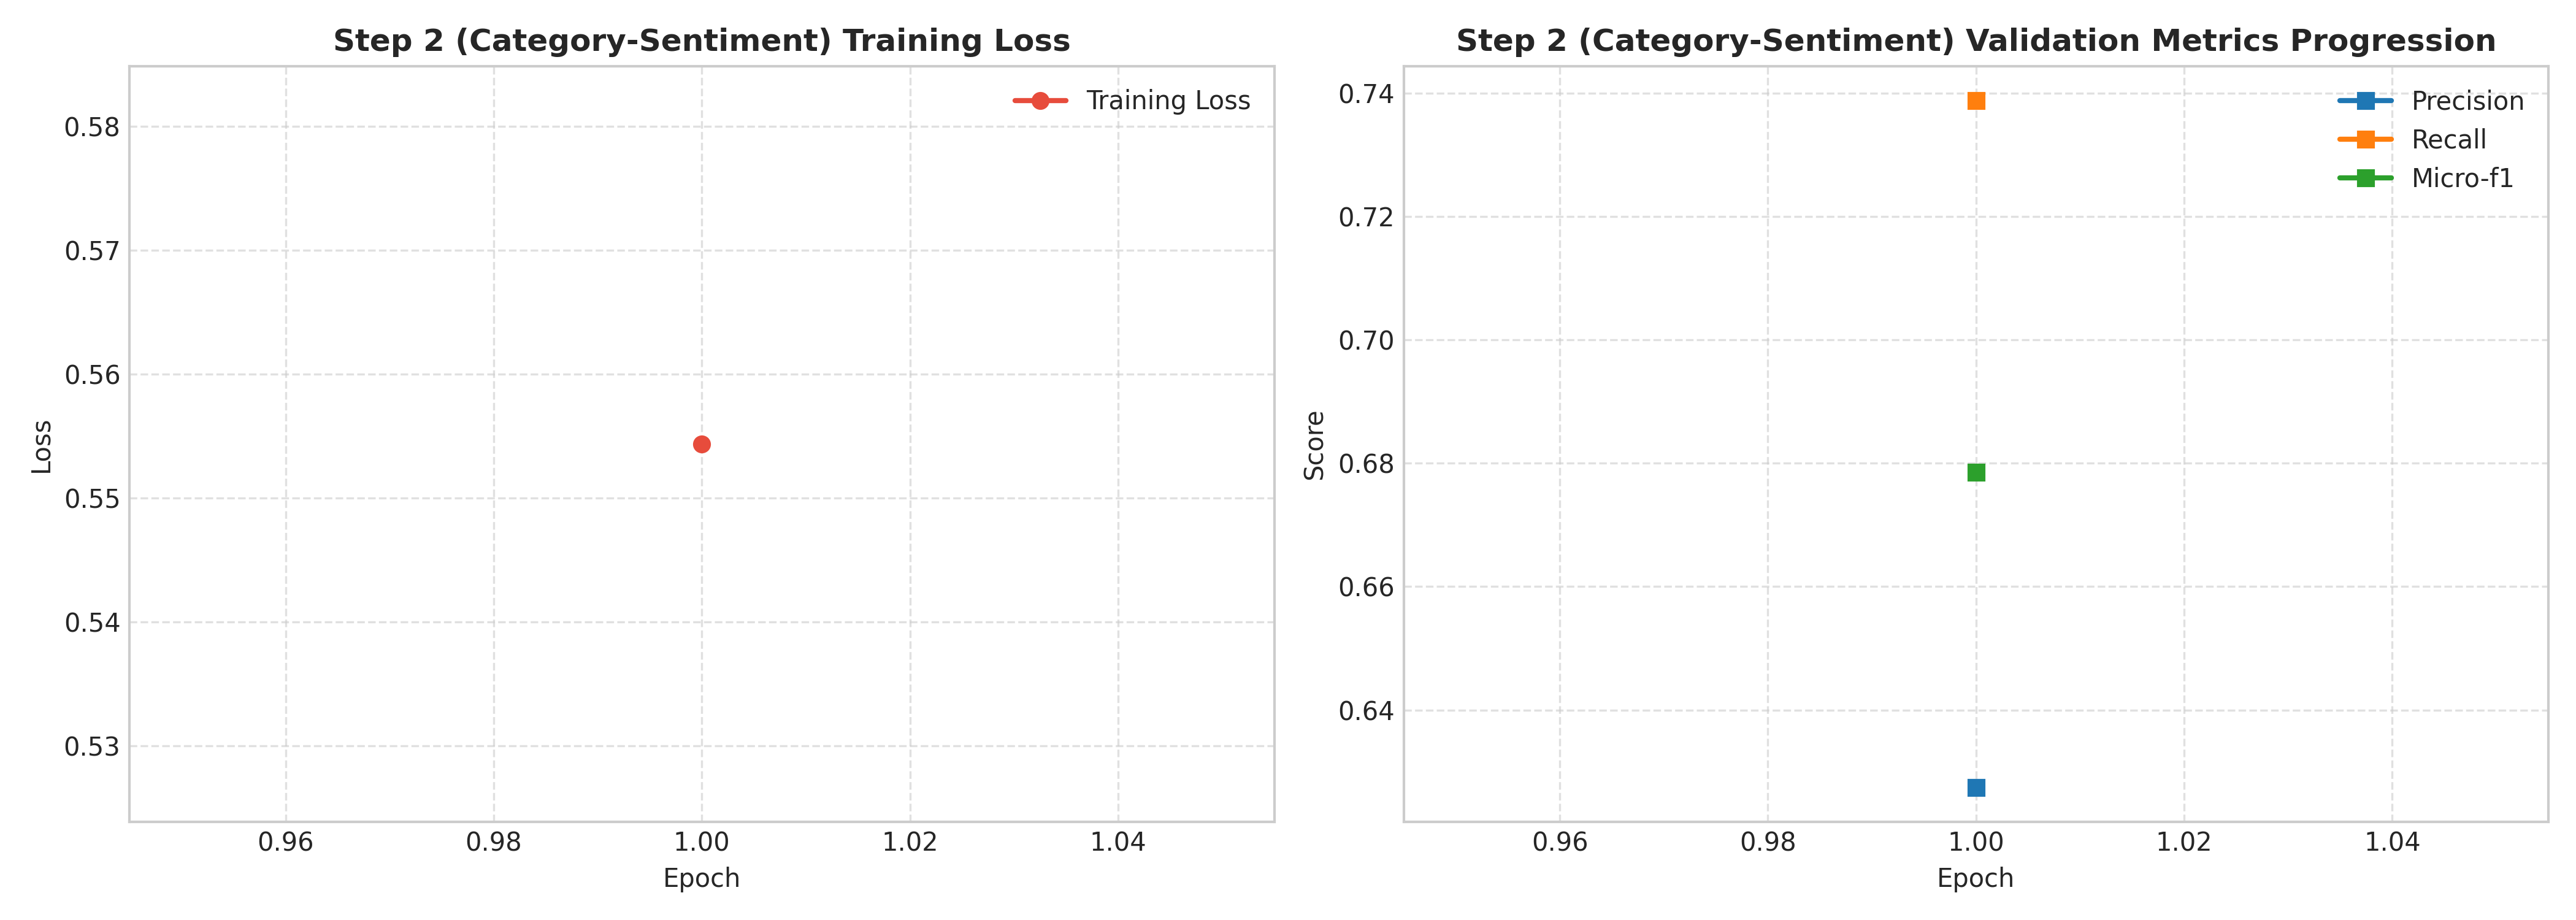

   [4/5]    1.0s  Manifest → STEP2_COMPLETED, pipeline_state.pkl diperbarui
✅ 8f. Plot, tabel laporan, manifest & state Step 2 — selesai dalam 1.0s



In [42]:
require_vars("step_stage", "step2_history", "best_step2_f1", "best2_epoch")

with step_stage("8f. Plot, tabel laporan, manifest & state Step 2", 5) as st:
    _p2 = os.path.join(plots_dir, "04_step2_training_loss_f1_curve.png")
    if step2_history:
        plot_training_history(
            step2_history, task_name="Step 2 (Category-Sentiment)",
            output_plot_path=_p2, output_csv_path=step2_csv
        )
        st.step(f"Plot & CSV riwayat ditulis ({len(step2_history)} epoch)")
    else:
        st.step("Riwayat kosong — plot dilewati")

    rep.section("5. Step 2: klasifikasi category & sentiment")
    df_s2_tabel = history_display_frame(step2_history)
    if not df_s2_tabel.empty:
        _kolom_hitung2 = [c for c in ("TP", "FP", "FN") if c in df_s2_tabel.columns]
        _src_txt = 'prediksi step 1' if globals().get('pakai_1st', True) else 'gold pair'
        export_step_table(df_s2_tabel, name="master_06_step2_riwayat", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Riwayat Training Step 2 ({DOMAIN.upper()})",
                          notes=("Metrik pada level quadruple lengkap. Sumber kandidat: "
                                 f"{_src_txt}. "
                                 + ("TP/FP/FN adalah hitungan mentah quadruple; "
                                    "Precision/Recall/Micro-F1 dalam persen."
                                    if _kolom_hitung2 else
                                    "Kolom TP/FP/FN tidak ada — riwayat berasal dari run "
                                    "sebelum patch metrik di sel 8a.")),
                          max_rows_md=NUM_EPOCHS)
        rep.table(df_s2_tabel, max_rows=NUM_EPOCHS, caption="Metrik step 2 per epoch")
        st.step(f"Tabel master_06_step2_riwayat diekspor (sumber kandidat: {_src_txt}, "
                f"kolom hitungan: {', '.join(_kolom_hitung2) or 'tidak ada'})")

        _row2, _f1_2, _ep2 = best_epoch_row(step2_history)
        rep.kv({
            "epoch_terbaik": _ep2 or best2_epoch,
            "micro-F1_terbaik": f"{_f1_2 * 100:.2f}%",
            "TP_FP_FN_epoch_terbaik": (
                f"{_row2.get('tp', float('nan')):.0f} / {_row2.get('fp', float('nan')):.0f} / "
                f"{_row2.get('fn', float('nan')):.0f}" if "tp" in _row2 else "tidak tercatat"),
            "checkpoint": step2_ckpt,
        })
        st.step(f"Micro-F1 terbaik {_f1_2 * 100:.2f}% (epoch {_ep2 or best2_epoch})")
    else:
        st.step("Tabel riwayat dilewati (tidak ada metrik per epoch)")

    if os.path.exists(_p2):
        from IPython.display import Image, display
        display(Image(_p2))
        rep.image(_p2, "Kurva training step 2")

    update_mcp_manifest("STEP2_COMPLETED", 5, {
        "step2_best_micro_f1": float(best_step2_f1 * 100 if best_step2_f1 <= 1.0 else best_step2_f1),
        "step2_checkpoint": step2_ckpt
    })
    save_pipeline_state({"best_step2_f1": best_step2_f1, "best_step2_epoch": best2_epoch})
    st.step("Manifest → STEP2_COMPLETED, pipeline_state.pkl diperbarui")

## 9. Evaluasi Final & Benchmark Sub-Task

### 9a. Evaluasi Quadruple dengan Checkpoint Terbaik
Memuat checkpoint Step 2 terbaik lalu menjalankan `pair_eval` sekali sambil menangkap
metrik per sub-task. **TP/FP/FN** ikut tersimpan — untuk metrik keseluruhan lewat patch
`measureQuad`, dan untuk tiap sub-task lewat `SubtaskMetricCapture`. Hasilnya di-cache ke
`logs/master_metrics.json`; set `FORCE_REEVAL = True` untuk mengevaluasi ulang.

In [44]:
ensure_objects()
require_vars("step_stage", "session_dirs")

# Evaluasi Final Memakai Checkpoint Model Step 2 Terbaik
FORCE_REEVAL = False

import logging
import eval_metrics as _em_final
from modeling import CategorySentiClassification
from eval_metrics import pair_eval
from colab_utils import SubtaskMetricCapture, plot_subtask_metrics

with step_stage("9a. Evaluasi final quadruple + metrik sub-task", 5) as st:
    metrics_json = os.path.join(session_dirs["logs"], "master_metrics.json")
    cached_metrics_available = os.path.exists(metrics_json)
    st.step(f"Cache metrik: {'ada' if cached_metrics_available else 'belum ada'} "
            f"({metrics_json}) | FORCE_REEVAL={FORCE_REEVAL}")

    if not FORCE_REEVAL and cached_metrics_available:
        with open(metrics_json, "r", encoding="utf-8") as jf:
            cached_all = json.load(jf)
        final_res = cached_all.get("overall", {})
        subtask_metrics = cached_all.get("subtasks", {})
        df_subtasks = pd.DataFrame([
            {"Subtask": k, "N_Elements": len(k.split()),
             "TP": v.get("tp", float("nan")), "FP": v.get("fp", float("nan")),
             "FN": v.get("fn", float("nan")),
             "Precision": v.get("precision", 0.0),
             "Recall": v.get("recall", 0.0), "Micro_F1": v.get("micro-F1", 0.0)}
            for k, v in subtask_metrics.items()
        ])
        st.step(f"[CACHE HIT] {len(final_res)} metrik keseluruhan, "
                f"{len(df_subtasks)} sub-task dimuat tanpa evaluasi ulang")
    else:
        if "eval_loader_2" not in globals() or "eval_gold_2" not in globals():
            raise RuntimeError(
                "Loader evaluasi Step 2 belum ada di memori dan master_metrics.json "
                "belum tersimpan. Jalankan sel 8c (dan 8a-8b) lebih dulu.")
        require_vars("args_h", "num_labels_step2", "label_list_step2")

        step2_ckpt_dir = session_dirs["step2_checkpoint"]
        os.makedirs(step2_ckpt_dir, exist_ok=True)
        step2_bin_path = os.path.join(step2_ckpt_dir, "pytorch_model.bin")

        # 1. Recovery langsung dari memori aktif (jika model_step2 baru saja dilatih di sel 8d/8e)
        if not os.path.exists(step2_bin_path) and "model_step2" in globals() and model_step2 is not None:
            torch.save(model_step2.state_dict(), step2_bin_path)
            if hasattr(model_step2, "config"):
                model_step2.config.to_json_file(os.path.join(step2_ckpt_dir, "config.json"))
            if "tokenizer" in globals() and tokenizer is not None:
                tokenizer.save_vocabulary(step2_ckpt_dir)
            st.note(f"💾 Checkpoint Step 2 berhasil disimpan dari model aktif di memori runtime → {step2_bin_path}")

        # 2. Fallback pencarian berkas lintas direktori sesi di Drive maupun lokal
        if not os.path.exists(step2_bin_path):
            _search_roots = [
                session_dirs.get("root", ""),
                results_base if 'results_base' in globals() else "",
                "/content/drive/MyDrive/ACOS/Output/results",
                "/content/drive/MyDrive/ACOS/results",
                "/content/drive/MyDrive/ACOS-ASLI/Output/results",
                "/content/drive/MyDrive/ACOS-ASLI/results",
                os.path.join(base_project_dir, "Output", "results") if 'base_project_dir' in globals() else "",
                os.path.join(base_project_dir, "results") if 'base_project_dir' in globals() else "",
            ]
            found_bin2 = auto_find_file("pytorch_model.bin", search_roots=_search_roots,
                                        must_contain="step2_best",
                                        domain=DOMAIN if 'DOMAIN' in globals() else None)
            if found_bin2 and os.path.exists(found_bin2):
                shutil.copy(found_bin2, step2_bin_path)
                src_dir2 = os.path.dirname(found_bin2)
                for fn in ["config.json", "vocab.txt"]:
                    fp = os.path.join(src_dir2, fn)
                    if os.path.exists(fp):
                        shutil.copy(fp, os.path.join(step2_ckpt_dir, fn))
                st.note(f"↪ Checkpoint Step 2 disalin dari {found_bin2}")

        # 3. Fallback darurat ke BERT pretrained cache jika checkpoint belum tersedia sama sekali
        if not os.path.exists(step2_bin_path):
            _bert_bin = os.path.join(bert_cache_dir, "pytorch_model.bin") if 'bert_cache_dir' in globals() else ""
            if _bert_bin and os.path.exists(_bert_bin):
                shutil.copy(_bert_bin, step2_bin_path)
                st.note(f"⚠️ Checkpoint Step 2 belum ada; menggunakan pretrained BERT cache sebagai fallback: {_bert_bin}")

        # 4. Pastikan file konfigurasi pendukung (config.json & vocab.txt) selalu ada
        for fn in ["config.json", "vocab.txt"]:
            dst_fp = os.path.join(step2_ckpt_dir, fn)
            if not os.path.exists(dst_fp) and 'bert_cache_dir' in globals():
                src_fp = os.path.join(bert_cache_dir, fn)
                if os.path.exists(src_fp):
                    shutil.copy(src_fp, dst_fp)

        if not os.path.exists(step2_bin_path):
            raise FileNotFoundError(
                f"Checkpoint Step 2 tidak ada di {step2_bin_path}. Jalankan sel 8e dulu.")
        st.step(f"Checkpoint dipakai: {step2_bin_path} "
                f"({os.path.getsize(step2_bin_path) / 1024 ** 2:.1f} MB)")

        if globals().get("USE_DUAL_HEAD", False):
            require_vars("num_labels_cat", "num_labels_senti")
            model_step2_best = CategorySentiDualHead.from_pretrained(
                session_dirs["step2_checkpoint"],
                num_categories=num_labels_cat,
                num_sentiments=num_labels_senti).to(device)
            st.step(f"Model terbaik dimuat: CategorySentiDualHead ({num_labels_cat} cat + {num_labels_senti} senti)")
        else:
            model_step2_best = CategorySentiClassification.from_pretrained(
                session_dirs["step2_checkpoint"], num_labels=num_labels_step2).to(device)
            st.step(f"Model terbaik dimuat: CategorySentiClassification ({num_labels_step2} label gabungan)")
        model_step2_best.eval()
        st.step(f"Model terbaik dimuat ke {device} dan diset ke mode eval")

        logger_final = logging.getLogger("Final_Eval")
        # Idempoten: 8a biasanya sudah memasangnya, tapi 9a bisa dijalankan
        # setelah restart kernel tanpa melewati 8a.
        patch_eval_metrics_counts()
        print(f"   Menjalankan pair_eval pada {len(eval_loader_2)} batch...", flush=True)
        with SubtaskMetricCapture(logger_final) as cap:
            final_res = pair_eval("final", args_h, logger_final, tokenizer, model_step2_best,
                                  eval_loader_2, eval_gold_2, label_list_step2, device,
                                  "categorysenti", eval_type="test")
        subtask_metrics = cap.to_dict()
        df_subtasks = cap.to_frame()
        _n_dgn_hitungan = sum(1 for v in subtask_metrics.values() if "tp" in v)
        st.step(f"pair_eval selesai: micro-F1 {final_res.get('micro-F1', 0.0) * 100:.2f}%, "
                f"{len(df_subtasks)} sub-task tertangkap "
                f"({_n_dgn_hitungan} dengan TP/FP/FN)")

        if globals().get("USE_DUAL_HEAD", False) and 'model_step2_best' in globals():
            # Evaluasi per head: category precision/recall F1 dan sentiment accuracy/macro-F1
            from sklearn.metrics import f1_score, accuracy_score
            import numpy as _np
            _cat_preds, _cat_golds = [], []
            _senti_preds, _senti_golds = [], []
            model_step2_best.eval()
            with torch.no_grad():
                for _batch in eval_loader_2:
                    _b = tuple(t.to(device) for t in _batch)
                    model_step2_best(tokenizer, 0, aspect_input_ids=_b[1],
                                    aspect_token_type_ids=_b[3], aspect_attention_mask=_b[2],
                                    candidate_aspect=_b[4], candidate_opinion=_b[5],
                                    label_id=_b[6])
                    _cl = getattr(model_step2_best, "latest_cat_logits", None)
                    _sl = getattr(model_step2_best, "latest_senti_logits", None)
                    if _cl is not None and _sl is not None:
                        _resh = _b[6].view(-1, 13, 3)
                        _ct = _resh.sum(dim=-1).clamp(max=1.0)
                        _sp = _resh.sum(dim=1)
                        _has_s = (_sp.sum(dim=-1) > 0)
                        _cat_preds.append((_cl.sigmoid() > 0.5).int().cpu().numpy())
                        _cat_golds.append(_ct.int().cpu().numpy())
                        if _has_s.any():
                            _senti_preds.append(_sl.argmax(dim=-1)[_has_s].cpu().numpy())
                            _senti_golds.append(_sp.argmax(dim=-1)[_has_s].cpu().numpy())
            _cg_arr = _np.vstack(_cat_golds) if _cat_golds else _np.array([])
            _cp_arr = _np.vstack(_cat_preds) if _cat_preds else _np.array([])
            _sg_arr = _np.concatenate(_senti_golds) if _senti_golds else _np.array([])
            _sp_arr = _np.concatenate(_senti_preds) if _senti_preds else _np.array([])
            _dh_metrics = {
                "category_micro_f1": float(f1_score(_cg_arr, _cp_arr, average="micro", zero_division=0)) if len(_cg_arr) else 0.0,
                "category_macro_f1": float(f1_score(_cg_arr, _cp_arr, average="macro", zero_division=0)) if len(_cg_arr) else 0.0,
                "sentiment_accuracy": float(accuracy_score(_sg_arr, _sp_arr)) if len(_sg_arr) else 0.0,
                "sentiment_macro_f1": float(f1_score(_sg_arr, _sp_arr, average="macro", zero_division=0)) if len(_sg_arr) else 0.0,
            }
            final_res["use_dual_head"] = True
            final_res["dual_head"] = _dh_metrics
            st.step(f"Dual-Head evaluasi mandiri | Cat micro-F1: {_dh_metrics['category_micro_f1']*100:.2f}% " +
                    f"macro-F1: {_dh_metrics['category_macro_f1']*100:.2f}% | " +
                    f"Senti Acc: {_dh_metrics['sentiment_accuracy']*100:.2f}% " +
                    f"macro-F1: {_dh_metrics['sentiment_macro_f1']*100:.2f}%")
        else:
            final_res["use_dual_head"] = False
        with open(metrics_json, "w", encoding="utf-8") as jf:
            json.dump({"overall": final_res, "subtasks": subtask_metrics,
                       "difficulty_breakdown": getattr(
                           _em_final, "LAST_DIFFICULTY_BREAKDOWN", []),
                       "step1_history": globals().get("step1_history", []),
                       "step2_history": globals().get("step2_history", []),
                       "sumber_kandidat": "step1" if globals().get("pakai_1st", True) else "gold",
                       "saved_at": datetime.now().isoformat()},
                      jf, indent=2)
        st.step(f"master_metrics.json tersimpan (TP/FP/FN keseluruhan + per sub-task): "
                f"{metrics_json}")

    print("\n🏆 Metrik Quadruple Akhir:")
    for k, v in final_res.items():
        if k in ("tp", "fp", "fn"):
            print(f"   {k.upper():15s}: {float(v):.0f}")
        elif isinstance(v, (int, float)) and not isinstance(v, bool):
            print(f"   {k:15s}: {float(v) * 100:.2f}%")
    if final_res.get("use_dual_head") and "dual_head" in final_res and isinstance(final_res["dual_head"], dict):
        print("\n🎯 Metrik Dual-Head (Evaluasi Mandiri):")
        for dk, dv in final_res["dual_head"].items():
            if isinstance(dv, (int, float)) and not isinstance(dv, bool):
                print(f"   {dk:22s}: {float(dv) * 100:.2f}%")


▶️  9a. Evaluasi final quadruple + metrik sub-task
   [1/5]    0.0s  Cache metrik: ada (/content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/logs/master_metrics.json) | FORCE_REEVAL=False
   [2/5]    0.0s  [CACHE HIT] 8 metrik keseluruhan, 15 sub-task dimuat tanpa evaluasi ulang

🏆 Metrik Quadruple Akhir:
   precision      : 62.74%
   recall         : 73.88%
   micro-F1       : 67.86%
   TP             : 6654
   FP             : 3951
   FN             : 2352

🎯 Metrik Dual-Head (Evaluasi Mandiri):
   category_micro_f1     : 0.00%
   category_macro_f1     : 0.00%
   sentiment_accuracy    : 0.00%
   sentiment_macro_f1    : 0.00%
✅ 9a. Evaluasi final quadruple + metrik sub-task — selesai dalam 0.0s



### 9b. Tabel & Plot Benchmark
Sel pelaporan murni: aman diulang tanpa menyentuh GPU. Tabel `master_07` memuat TP/FP/FN
sebagai hitungan mentah dan precision/recall/micro-F1 dalam persen; `master_08` menampilkan
kolom yang sama untuk tiap sub-task.

▶️  9b. Tabel & plot benchmark sub-task
=== Metrik Akhir Ekstraksi Quadruple (APPSID) (6 baris) ===


,Metrik,Jenis,Nilai,Tampil
0,precision,laju,0.627440,62.74%
1,recall,laju,0.738841,73.88%
2,micro-F1,laju,0.678599,67.86%
3,TP,hitungan,6654.000000,6654
4,FP,hitungan,3951.000000,3951
5,FN,hitungan,2352.000000,2352


[tabel] CSV: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/csv/master_07_metrik_quadruple_final.csv | MD: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/md/master_07_metrik_quadruple_final.md
=== Metrik Mandiri Dual-Head Step 2 (APPSID) (4 baris) ===


,Metrik,Nilai_%
0,category_micro_f1,0.00%
1,category_macro_f1,0.00%
2,sentiment_accuracy,0.00%
3,sentiment_macro_f1,0.00%


[tabel] CSV: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/csv/master_07b_metrik_dualhead.csv | MD: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/md/master_07b_metrik_dualhead.md
   [1/5]    0.1s  Tabel master_07b diekspor (Dual-Head mandiri: 4 metrik)
   [2/5]    0.1s  Tabel master_07 diekspor | sumber kandidat: prediksi step 1 (skor pipeline penuh) | TP/FP/FN: ada
=== Metrik per Sub-Task (APPSID) - 15 kombinasi (15 baris) ===


,Subtask,N_Elements,TP,FP,FN,Precision,Recall,Micro_F1
0,category,1,16477.0,1142.0,1563.0,93.52,91.34,92.41
1,sentiment,1,13137.0,2248.0,2398.0,85.39,84.56,84.97
2,category sentiment,2,14142.0,3755.0,3947.0,79.02,78.18,78.60
3,aspect,1,18019.0,853.0,1498.0,95.48,92.32,93.88
4,category aspect,2,17491.0,1644.0,2026.0,91.41,89.62,90.51
5,sentiment aspect,2,15402.0,3769.0,4126.0,80.34,78.87,79.60
6,category sentiment aspect,3,14920.0,4514.0,4608.0,76.77,76.40,76.59
7,opinion,1,16896.0,516.0,786.0,97.04,95.55,96.29
8,category opinion,2,16878.0,4659.0,1994.0,78.37,89.43,83.54
9,sentiment opinion,2,14703.0,2905.0,2979.0,83.50,83.15,83.33


[tabel] CSV: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/csv/master_08_metrik_subtask.csv | MD: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/md/master_08_metrik_subtask.md
   [3/5]    0.1s  Tabel master_08 diekspor (15 sub-task, hitungan: TP, FP, FN)


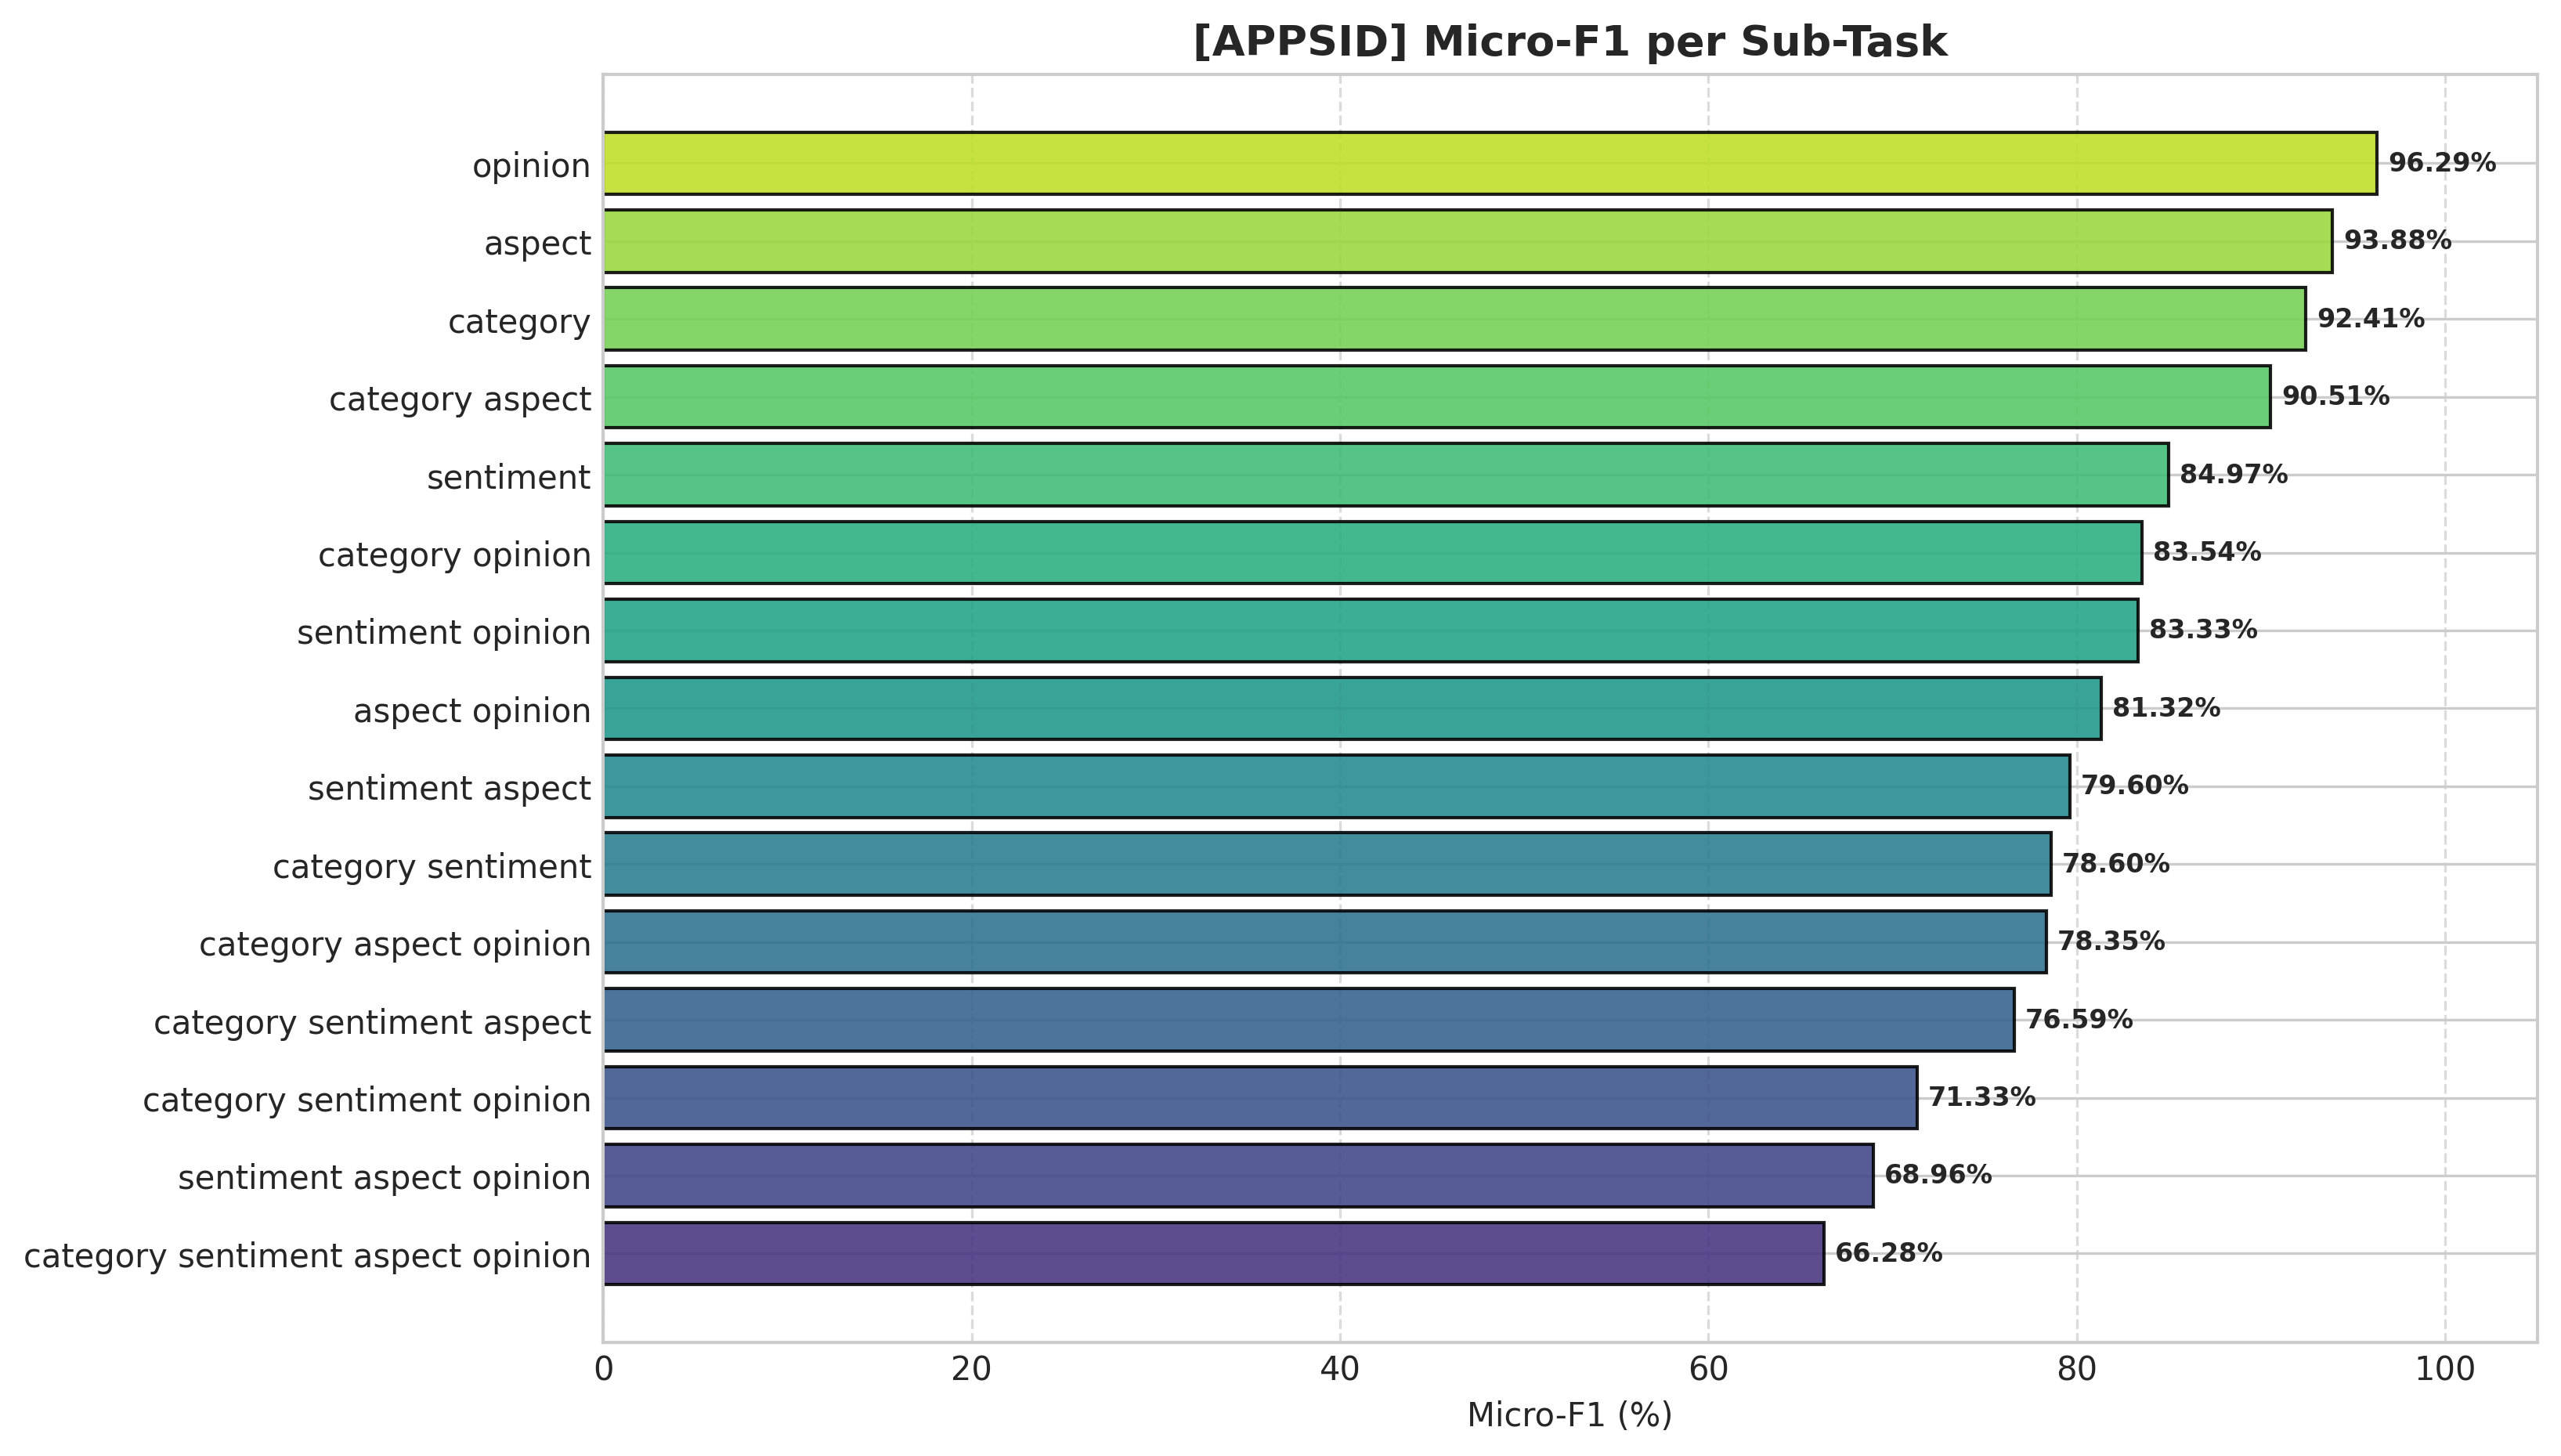

[plot] Disimpan: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/plots/05_benchmark_subtasks_f1.png
   [4/5]    1.2s  Plot benchmark disimpan: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/plots/05_benchmark_subtasks_f1.png
=== Micro-F1 Menurut Jumlah Elemen (APPSID) (4 baris) ===


,N_Elements,Jumlah_Subtask,Micro_F1_Rata2,Micro_F1_Min,Micro_F1_Maks,TP_Total,FP_Total,FN_Total
0,1,4,91.89,84.97,96.29,64529.0,4759.0,6245.0
1,2,6,82.82,78.60,90.51,96220.0,22896.0,16996.0
2,3,4,73.81,68.96,78.35,61353.0,27489.0,16103.0
3,4,1,66.28,66.28,66.28,14448.0,9618.0,5080.0


[tabel] CSV: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/csv/master_09_agregasi_elemen.csv | MD: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/md/master_09_agregasi_elemen.md
   [5/5]    1.3s  Agregasi per jumlah elemen diekspor (4 baris)
   [6/5]    1.3s  Manifest → FINAL_EVAL_COMPLETED, pipeline_state.pkl diperbarui
✅ 9b. Tabel & plot benchmark sub-task — selesai dalam 1.3s



In [52]:
require_vars("step_stage", "final_res", "df_subtasks")

with step_stage("9b. Tabel & plot benchmark sub-task", 5) as st:
    rep.section("6. Hasil akhir pipeline")
    df_overall = metrics_display_frame(final_res)
    df_overall = df_overall[~df_overall["Metrik"].isin(["use_dual_head", "dual_head"])].reset_index(drop=True)
    _sumber = ('prediksi step 1 (skor pipeline penuh)' if globals().get('pakai_1st', True)
               else 'gold pair (step 2 terisolasi)')
    _ada_hitungan_final = "hitungan" in set(df_overall.get("Jenis", []))
    export_step_table(df_overall, name="master_07_metrik_quadruple_final",
                      csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Metrik Akhir Ekstraksi Quadruple ({DOMAIN.upper()})",
                      notes=(f"Sumber kandidat: {_sumber}. "
                             + ("Baris berjenis 'hitungan' (TP/FP/FN) adalah jumlah "
                                "quadruple, bukan persentase."
                                if _ada_hitungan_final else
                                "TP/FP/FN tidak tersedia — metrik ini dimuat dari cache "
                                "master_metrics.json sebelum patch sel 8a. Set "
                                "FORCE_REEVAL=True di sel 9a untuk menghitung ulang.")))
    rep.table(df_overall, caption="Metrik quadruple akhir")
    if final_res.get("use_dual_head") and "dual_head" in final_res and isinstance(final_res["dual_head"], dict):
        df_dual = pd.DataFrame([
            {"Metrik": k, "Nilai_%": f"{float(v) * 100:.2f}%"}
            for k, v in final_res["dual_head"].items()
            if isinstance(v, (int, float)) and not isinstance(v, bool)
        ])
        if not df_dual.empty:
            export_step_table(df_dual, name="master_07b_metrik_dualhead",
                              csv_dir=csv_dir, md_dir=md_dir,
                              title=f"Metrik Mandiri Dual-Head Step 2 ({DOMAIN.upper()})")
            rep.table(df_dual, caption="Metrik mandiri dual-head Step 2")
            st.step(f"Tabel master_07b diekspor (Dual-Head mandiri: {len(df_dual)} metrik)")
    st.step(f"Tabel master_07 diekspor | sumber kandidat: {_sumber} | "
            f"TP/FP/FN: {'ada' if _ada_hitungan_final else 'tidak ada'}")

    if not df_subtasks.empty:
        df_sub_pct = df_subtasks.copy()
        for c in ["Precision", "Recall", "Micro_F1"]:
            if c in df_sub_pct.columns and df_sub_pct[c].max() <= 1.0:
                df_sub_pct[c] = (df_sub_pct[c] * 100).round(2)
        for c in ["TP", "FP", "FN"]:
            if c in df_sub_pct.columns:
                df_sub_pct[c] = pd.to_numeric(df_sub_pct[c], errors="coerce").round(0)
        _kolom_hitung_sub = [c for c in ("TP", "FP", "FN")
                             if c in df_sub_pct.columns and df_sub_pct[c].notna().any()]

        rep.section("7. Metrik per sub-task")
        export_step_table(df_sub_pct, name="master_08_metrik_subtask", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Metrik per Sub-Task ({DOMAIN.upper()}) - {len(df_sub_pct)} kombinasi",
                          notes=("Diambil dari keluaran pair_eval sesi ini, bukan angka manual. "
                                 + (f"Kolom hitungan mentah: {', '.join(_kolom_hitung_sub)}."
                                    if _kolom_hitung_sub else
                                    "TP/FP/FN kosong — sub-task ini ditangkap sebelum patch "
                                    "metrik aktif.")),
                          max_rows_md=20)
        rep.table(df_sub_pct, max_rows=20, caption="Metrik per sub-task")
        st.step(f"Tabel master_08 diekspor ({len(df_sub_pct)} sub-task, "
                f"hitungan: {', '.join(_kolom_hitung_sub) or 'tidak ada'})")

        _ps = os.path.join(plots_dir, "05_benchmark_subtasks_f1.png")
        plot_subtask_metrics(df_subtasks, _ps,
                             title=f"[{DOMAIN.upper()}] Micro-F1 per Sub-Task")
        rep.image(_ps, "Micro-F1 per sub-task")
        st.step(f"Plot benchmark disimpan: {_ps}")

        _agg_spec = {"Jumlah_Subtask": ("Subtask", "count"),
                     "Micro_F1_Rata2": ("Micro_F1", "mean"),
                     "Micro_F1_Min": ("Micro_F1", "min"),
                     "Micro_F1_Maks": ("Micro_F1", "max")}
        for _c, _label in (("TP", "TP_Total"), ("FP", "FP_Total"), ("FN", "FN_Total")):
            if _c in df_subtasks.columns and df_subtasks[_c].notna().any():
                _agg_spec[_label] = (_c, "sum")
        df_agg = df_subtasks.groupby("N_Elements").agg(**_agg_spec).reset_index()
        for c in ["Micro_F1_Rata2", "Micro_F1_Min", "Micro_F1_Maks"]:
            if df_agg[c].max() <= 1.0:
                df_agg[c] = (df_agg[c] * 100).round(2)
        for c in ["TP_Total", "FP_Total", "FN_Total"]:
            if c in df_agg.columns:
                df_agg[c] = df_agg[c].round(0)
        export_step_table(df_agg, name="master_09_agregasi_elemen", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Micro-F1 Menurut Jumlah Elemen ({DOMAIN.upper()})",
                          notes=("TP/FP/FN_Total adalah jumlah hitungan mentah seluruh "
                                 "sub-task pada jumlah elemen yang sama."
                                 if "TP_Total" in df_agg.columns else None))
        rep.table(df_agg, caption="Agregasi per jumlah elemen")
        st.step(f"Agregasi per jumlah elemen diekspor ({len(df_agg)} baris)")
    else:
        st.step("df_subtasks kosong — tabel dan plot sub-task dilewati")

    update_mcp_manifest("FINAL_EVAL_COMPLETED", 6, {
        "final_metrics": final_res, "metrics_json_path": metrics_json
    })
    save_pipeline_state({"final_res": final_res})
    st.step("Manifest → FINAL_EVAL_COMPLETED, pipeline_state.pkl diperbarui")

## 10. Live Interactive Inference Demo pada Teks Ulasan Bebas

In [46]:
ensure_objects()
import re as _re

# Kelas model diimpor di sel 12 & 22; ambil ulang bila sel ini dijalankan
# sendiri sesudah pemulihan state.
from modeling import BertForQuadABSA, CategorySentiClassification


In [48]:

# Muat model Step 1 & Step 2 terbaik untuk inferensi live (dengan fallback auto-load)
step1_best_path = session_dirs["step1_checkpoint"]
if not os.path.exists(os.path.join(step1_best_path, "pytorch_model.bin")):
    found_b1 = auto_find_file("pytorch_model.bin", must_contain="step1_best")
    if found_b1 and "step1_best" in found_b1:
        step1_best_path = os.path.dirname(found_b1)

step2_best_path = session_dirs["step2_checkpoint"]
if not os.path.exists(os.path.join(step2_best_path, "pytorch_model.bin")):
    found_b2 = auto_find_file("pytorch_model.bin", must_contain="step2_best")
    if found_b2 and "step2_best" in found_b2:
        step2_best_path = os.path.dirname(found_b2)

model_step1_best = BertForQuadABSA.from_pretrained(
    step1_best_path, num_labels=num_labels_step1).to(device)
model_step1_best.eval()

model_step2_best = CategorySentiClassification.from_pretrained(
    step2_best_path, num_labels=num_labels_step2).to(device)
model_step2_best.eval()

_catsenti_labels = label_list_step2[0]

def _spans_dari_tag(tag_ids):
    s = "".join(str(t) for t in tag_ids)
    aspects = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"32*", s)]
    opinions = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"54*", s)]
    return aspects, opinions


In [49]:

def analyze_review_quadruples(review_text, domain=None, ambang=0.0, tampilkan_proses=True):
    """Ekstraksi quadruple dua tahap untuk satu teks ulasan bebas."""
    domain = domain or DOMAIN
    max_len = MAX_SEQ_LENGTH

    tokens = tokenizer.tokenize(review_text.lower())[: max_len - 2]
    input_tokens = ["[CLS]"] + tokens + ["[SEP]"]
    input_ids = tokenizer.convert_tokens_to_ids(input_tokens)
    attn = [1] * len(input_ids)
    seg = [0] * len(input_ids)
    while len(input_ids) < max_len:
        input_ids.append(0)
        attn.append(0)
        seg.append(0)

    t_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    t_attn = torch.tensor([attn], dtype=torch.long).to(device)
    t_seg = torch.tensor([seg], dtype=torch.long).to(device)
    t_dummy = torch.zeros((1, max_len), dtype=torch.long).to(device)
    t_zero = torch.zeros(1, dtype=torch.long).to(device)

    with torch.no_grad():
        out1 = model_step1_best(
            aspect_input_ids=t_ids, aspect_labels=t_dummy,
            aspect_token_type_ids=t_seg, aspect_attention_mask=t_attn,
            exist_imp_aspect=t_zero, exist_imp_opinion=t_zero,
        )
    _, logits1 = unpack_model_output(out1)
    pred_tags, imp_a_logit, imp_o_logit = logits1
    imp_aspect = int(imp_a_logit.argmax(-1).item()) == 1
    imp_opinion = int(imp_o_logit.argmax(-1).item()) == 1

    aspects, opinions = _spans_dari_tag(pred_tags[0])
    if imp_aspect or not aspects:
        aspects = aspects + [(-1, -1)]
    if imp_opinion or not opinions:
        opinions = opinions + [(-1, -1)]

    if tampilkan_proses:
        print(f"\nTeks Review : {review_text}")
        print(f"Tokens      : {tokens}")
        print(f"Aspect Spans: {aspects} (implicit={imp_aspect})")
        print(f"Opinion Span: {opinions} (implicit={imp_opinion})")

    hasil = []
    for (a_st, a_ed) in aspects:
        for (o_st, o_ed) in opinions:
            cand_a = [0] * max_len
            cand_o = [0] * max_len
            if a_st == -1:
                cand_a[0] = 1
            else:
                for i in range(a_st + 1, a_ed + 1):
                    if i < max_len: cand_a[i] = 1
            if o_st == -1:
                cand_o[len(tokens) + 1] = 1
            else:
                for i in range(o_st + 1, o_ed + 1):
                    if i < max_len: cand_o[i] = 1

            with torch.no_grad():
                out2 = model_step2_best(
                    tokenizer, 0,
                    aspect_input_ids=t_ids,
                    aspect_token_type_ids=t_seg,
                    aspect_attention_mask=t_attn,
                    candidate_aspect=torch.tensor([cand_a], dtype=torch.long).to(device),
                    candidate_opinion=torch.tensor([cand_o], dtype=torch.long).to(device),
                    label_id=torch.zeros((1, num_labels_step2), dtype=torch.float).to(device),
                )
            _, logits2 = unpack_model_output(out2)
            skor = logits2[0][0].detach().cpu().numpy()

            aktif = [i for i, v in enumerate(skor) if v > ambang] or [int(skor.argmax())]
            asp_txt = "[IMPLICIT]" if a_st == -1 else " ".join(tokens[a_st:a_ed])
            opi_txt = "[IMPLICIT]" if o_st == -1 else " ".join(tokens[o_st:o_ed])

            for idx in aktif:
                kategori, sentimen = _catsenti_labels[idx].rsplit("#", 1)
                hasil.append({
                    "Aspect": asp_txt,
                    "Aspect_Span": f"{a_st},{a_ed}",
                    "Category": kategori,
                    "Opinion": opi_txt,
                    "Opinion_Span": f"{o_st},{o_ed}",
                    "Sentiment": {"0": "negative", "1": "neutral", "2": "positive"}.get(sentimen, sentimen),
                    "Skor_Logit": round(float(skor[idx]), 4),
                    "Is_Implicit_Aspect": a_st == -1,
                    "Is_Implicit_Opinion": o_st == -1,
                })

    df = pd.DataFrame(hasil)
    if not df.empty:
        df = df.sort_values("Skor_Logit", ascending=False).reset_index(drop=True)
    return df

# Contoh Pengujian Live Review — dipilih menurut bahasa domain.
SAMPLE_REVIEWS = {
    "appsid": "transfer nya cepat tapi aplikasi sering error saat buka menu",
    "rest16": "The sushi was fresh and delicious, but the service was slow.",
    "laptop": "The battery life is great but the keyboard feels cheap.",
}
sample_review = SAMPLE_REVIEWS.get(DOMAIN, SAMPLE_REVIEWS["appsid"])
df_infer = analyze_review_quadruples(sample_review, domain=DOMAIN)

rep.section("8. Contoh inferensi")
rep.text(f"Teks: `{sample_review}`")
if not df_infer.empty:
    export_step_table(df_infer, name="master_10_contoh_inferensi", csv_dir=csv_dir, md_dir=md_dir,
                      title="Quadruple Hasil Inferensi Contoh",
                      notes="Skor_Logit adalah keluaran mentah sebelum sigmoid; ambang default 0.0.",
                      max_rows_md=20)
    rep.table(df_infer, max_rows=20, caption="Quadruple hasil inferensi")
    from IPython.display import display
    display(df_infer)

save_pipeline_state({"df_infer": df_infer})


Teks Review : transfer nya cepat tapi aplikasi sering error saat buka menu
Tokens      : ['transfer', 'nya', 'cepat', 'tapi', 'aplikasi', 'sering', 'error', 'saat', 'buka', 'menu']
Aspect Spans: [(0, 1), (9, 10)] (implicit=False)
Opinion Span: [(2, 3), (5, 7)] (implicit=False)
=== Quadruple Hasil Inferensi Contoh (89 baris) ===


/usr/local/lib/python3.13/dist-packages/torchcrf/__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:614.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)


,Aspect,Aspect_Span,Category,Opinion,Opinion_Span,Sentiment,Skor_Logit,Is_Implicit_Aspect,Is_Implicit_Opinion
0,transfer,"0,1",NOTIFICATION_INFO,sering error,"5,7",neutral,2.2075,False,False
1,transfer,"0,1",NOTIFICATION_INFO,cepat,"2,3",neutral,2.0027,False,False
2,menu,"9,10",NOTIFICATION_INFO,sering error,"5,7",neutral,1.8328,False,False
3,menu,"9,10",NOTIFICATION_INFO,cepat,"2,3",neutral,1.6280,False,False
4,menu,"9,10",FEATURES_PRODUCT,sering error,"5,7",neutral,1.5587,False,False
5,transfer,"0,1",UI_UX_DESIGN,sering error,"5,7",negative,1.5360,False,False
6,transfer,"0,1",FEATURES_PRODUCT,sering error,"5,7",negative,1.4608,False,False
7,menu,"9,10",FEATURES_PRODUCT,cepat,"2,3",neutral,1.4175,False,False
8,menu,"9,10",CUSTOMER_SERVICE,cepat,"2,3",neutral,1.2894,False,False
9,transfer,"0,1",FEATURES_PRODUCT,sering error,"5,7",neutral,1.2377,False,False


[tabel] CSV: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/csv/master_10_contoh_inferensi.csv | MD: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/md/master_10_contoh_inferensi.md


,Aspect,Aspect_Span,Category,Opinion,Opinion_Span,Sentiment,Skor_Logit,Is_Implicit_Aspect,Is_Implicit_Opinion
0,transfer,"0,1",NOTIFICATION_INFO,sering error,"5,7",neutral,2.2075,False,False
1,transfer,"0,1",NOTIFICATION_INFO,cepat,"2,3",neutral,2.0027,False,False
2,menu,"9,10",NOTIFICATION_INFO,sering error,"5,7",neutral,1.8328,False,False
3,menu,"9,10",NOTIFICATION_INFO,cepat,"2,3",neutral,1.6280,False,False
4,menu,"9,10",FEATURES_PRODUCT,sering error,"5,7",neutral,1.5587,False,False
...,...,...,...,...,...,...,...,...,...
84,transfer,"0,1",TRANSACTION_TRANSFER,sering error,"5,7",positive,0.0638,False,False
85,menu,"9,10",APP_PERFORMANCE,cepat,"2,3",neutral,0.0408,False,False
86,transfer,"0,1",INTEREST_RETURNS,sering error,"5,7",positive,0.0373,False,False
87,menu,"9,10",UI_UX_DESIGN,sering error,"5,7",neutral,0.0289,False,False


'/content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437/pipeline_state.pkl'

## 11. Ringkasan Seluruh Artefak & Finalisasi Sesi

In [53]:
# Audit akhir seluruh artefak tersimpan di Google Drive / lokal
print("=" * 78)
print(f"🏁 AUDIT ARTEFAK SESI AKTIF [{DOMAIN.upper()}]")
print("=" * 78)
print(f"📁 Lokasi Penyimpanan: {session_dirs.get('root')}")
is_drive_saved = "/content/drive/MyDrive" in session_dirs.get("root", "")
print(f"🛡️  Persistensi Google Drive: {'✅ TERSIMPAN DI DRIVE' if is_drive_saved else '⚠️ LOKAL / EPHEMERAL'}\n")

all_saved_files = []
for sub_name, sub_path in session_dirs.items():
    if sub_name == "root" or not os.path.isdir(sub_path):
        continue
    for root, dirs, files in os.walk(sub_path):
        for f in sorted(files):
            fp = os.path.join(root, f)
            sz = os.path.getsize(fp)
            all_saved_files.append({
                "Subfolder": sub_name,
                "File": f,
                "Size": f"{sz / 1024:.1f} KB" if sz < 1024*1024 else f"{sz / (1024**2):.2f} MB",
                "Path": fp
            })

df_audit = pd.DataFrame(all_saved_files)
if not df_audit.empty:
    print(f"📦 Total {len(df_audit)} file berhasil diamankan di sesi ini:")
    for sf, grp in df_audit.groupby("Subfolder"):
        print(f"\n📂 [{sf.upper()}] ({len(grp)} file):")
        for r in grp.itertuples():
            print(f"   - {r.File:<42} ({r.Size})")
else:
    print("⚠️ Belum ada file tersimpan di subfolder sesi.")
print("=" * 78)


🏁 AUDIT ARTEFAK SESI AKTIF [APPSID]
📁 Lokasi Penyimpanan: /content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results/appsid_08092026_150437
🛡️  Persistensi Google Drive: ✅ TERSIMPAN DI DRIVE

📦 Total 80 file berhasil diamankan di sesi ini:

📂 [CHECKPOINTS] (10 file):
   - config.json                                (1.5 KB)
   - pytorch_model.bin                          (477.07 MB)
   - vocab.txt                                  (223.8 KB)
   - config.json                                (1.5 KB)
   - pytorch_model.bin                          (474.88 MB)
   - vocab.txt                                  (223.8 KB)
   - optimizer.pt                               (949.59 MB)
   - pytorch_model.bin                          (477.07 MB)
   - optimizer.pt                               (945.21 MB)
   - pytorch_model.bin                          (474.88 MB)

📂 [CSV] (22 file):
   - candidate_pairs_summary.csv                (851.2 KB)
   - eda_all_samples_annotated.csv              (10.15 MB)
   - e